In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/raw/Bank Customer Churn Prediction.csv")
df.drop("customer_id", axis=1, inplace=True)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Convertir variables categoricas con one hot encoding
df = pd.get_dummies(
    df,
    columns=["country", "gender"],
    drop_first=True
)

df.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [5]:
# Separar target 
X = df.drop("churn", axis=1)
y = df["churn"]

In [6]:
# Usamos stratify split porque el dataset es desbalanceado
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
# Para usar logistic regression y SVM es necesario escalar
# Para Random Forest o XGBoost no es necesario
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None
    print("\nAccuracy")
    print(
        accuracy_score(
            y_test,
            y_pred
        )
    )
    print("\nPrecision")
    print(
        precision_score(
            y_test,
            y_pred
        )
    )
    print("\nRecall")
    print(
        recall_score(
            y_test,
            y_pred
        )
    )
    print("\nF1")
    print(
        f1_score(
            y_test,
            y_pred
        )
    )
    if y_prob is not None:
        print("\nROC AUC")
        print(
            roc_auc_score(
                y_test,
                y_prob
            )
        )
    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )
    cm = confusion_matrix(
        y_test,
        y_pred
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )
    plt.show()


Accuracy
0.8635

Precision
0.7701612903225806

Recall
0.4692874692874693

F1
0.583206106870229

ROC AUC
0.8533934550883704

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



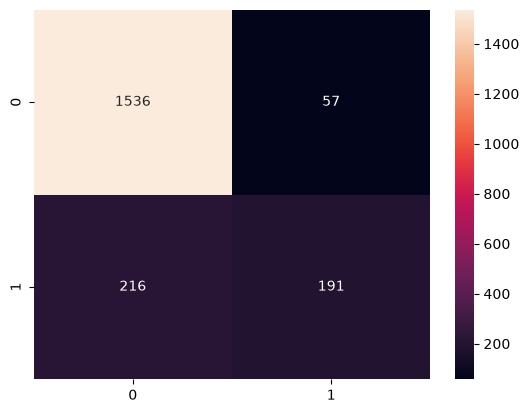

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

In [10]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance":
    rf_model.feature_importances_

})

In [11]:
feature_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
1,age,0.237503
7,estimated_salary,0.147119
0,credit_score,0.142947
3,balance,0.142377
4,products_number,0.128088
2,tenure,0.081545
6,active_member,0.040445
8,country_Germany,0.028709
5,credit_card,0.019218
10,gender_Male,0.018368


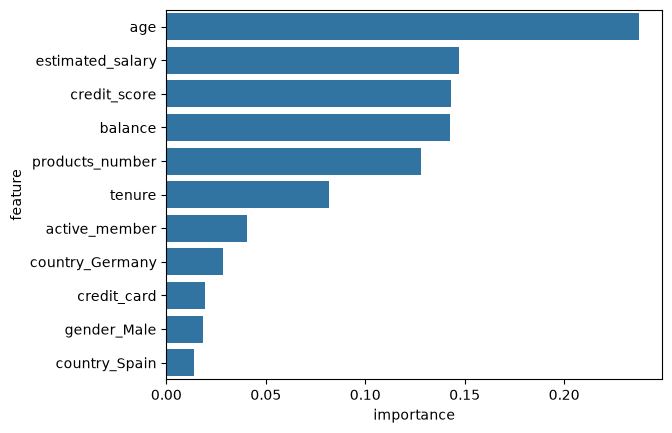

In [12]:
sns.barplot(
    data=feature_importance.sort_values(
        "importance",
        ascending=False
    ).head(15),
    x="importance",
    y="feature"
)

plt.show()

## XGBOOST

In [13]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)


Accuracy
0.869

Precision
0.7821011673151751

Recall
0.49385749385749383

F1
0.6054216867469879

ROC AUC
0.8622227774770148

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



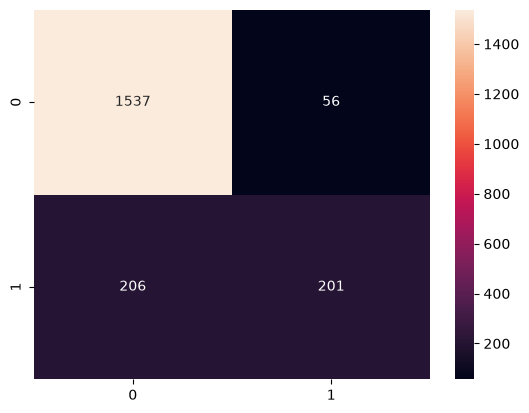

In [15]:
evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

In [16]:
train_pred = xgb_model.predict(X_train)
test_pred = xgb_model.predict(X_test)

In [17]:
print(
    "Train Accuracy:",
    accuracy_score(
        y_train,
        train_pred
    )
)

Train Accuracy: 0.899375


In [18]:
print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        test_pred
    )
)

Test Accuracy: 0.869


## Aplicamos Stratified Kfold

In [19]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

In [21]:
print(cv_scores)

[0.8665024  0.85095976 0.86272096 0.86304641 0.86968941]


## Optimizacion de hiperparametros

In [22]:
param_grid = {
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "n_estimators":[100,300]
}

In [23]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

In [24]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [25]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

In [26]:
grid_search.best_score_

np.float64(0.8646794751243384)

In [27]:
y_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [28]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

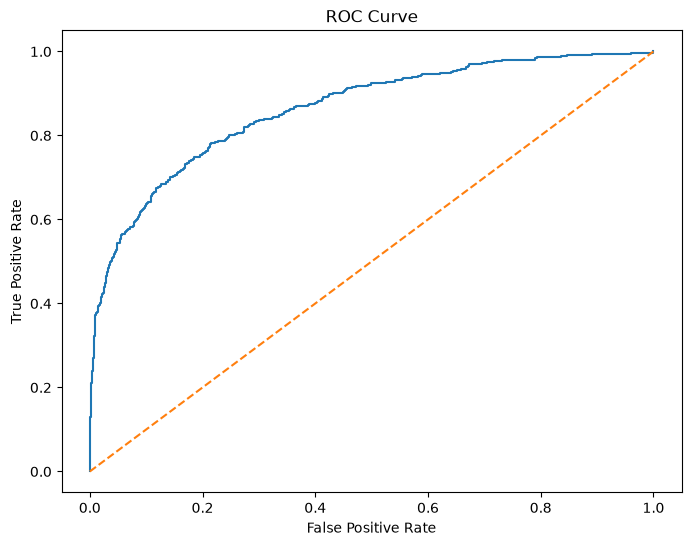

In [29]:
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Usamos ML Flow para versionado de modelo

In [30]:
import mlflow
import mlflow.sklearn
with mlflow.start_run():
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
    xgb.fit(
        X_train,
        y_train
    )
    preds = xgb.predict(
        X_test
    )
    probs = xgb.predict_proba(
        X_test
    )[:,1]
    acc = accuracy_score(
        y_test,
        preds
    )
    auc = roc_auc_score(
        y_test,
        probs
    )
    mlflow.log_param(
        "n_estimators",
        300
    )
    mlflow.log_param(
        "learning_rate",
        0.05
    )
    mlflow.log_param(
        "max_depth",
        5
    )
    mlflow.log_metric(
        "accuracy",
        acc
    )
    mlflow.log_metric(
        "roc_auc",
        auc
    )
    mlflow.sklearn.log_model(
        xgb,
        "xgboost_model"
    )

2026/06/15 18:00:53 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/15 18:00:53 INFO mlflow.store.db.utils: Updating database tables
2026/06/15 18:00:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 18:00:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [31]:
mlflow.sklearn.log_model(
    xgb,
    artifact_path="model",
    registered_model_name="ChurnPrediction"
)

2026/06/15 18:01:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 18:01:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'ChurnPrediction'.
Created version '1' of model 'ChurnPrediction'.


In [33]:
import joblib
joblib.dump(
    xgb_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']